In [1]:
import pandas as pd             # data package
import matplotlib.pyplot as plt # graphics 
import datetime as dt
import numpy as np
from scipy.stats.mstats import gmean

import matplotlib.ticker as mtick 

import requests, io             # internet and input tools  
import zipfile as zf            # zip file tools 
import os  

#import weightedcalcs as wc
#import numpy as np

import pyarrow as pa
import pyarrow.parquet as pq

In [2]:
figfile = "C:\\github\\how-restrictive-us-trade\\figures\\"

In [3]:
my_key = "&key=34e40301bda77077e24c859c6c6c0b721ad73fc7"
# This is my key. I'm nice and I have it posted. If you will be doing more with this
# please get your own key!

end_use = "naics?get=CON_VAL_MO,CTY_CODE,CTY_NAME,SUMMARY_LVL"

url = "https://api.census.gov/data/timeseries/intltrade/imports/" + end_use 
url = url + my_key + "&time==from+2013-01"

r = requests.get(url) 
    
print(r)
    
df = pd.DataFrame(r.json()[1:]) # This then converts it to a dataframe
    # Note that the first entry is the labels

df.columns = r.json()[0]

df["total_imports"] = df["CON_VAL_MO"].astype(float)

df = df[df.SUMMARY_LVL == "DET"]

grp = df.groupby(["CTY_NAME"])

top_products = grp.agg({"total_imports":"sum","CTY_CODE":"first"})

country_list = list(top_products.sort_values(by = "total_imports", ascending = False).CTY_CODE)[0:31]

country_list.remove("-")

pd.DataFrame(country_list).to_csv('.\data\country-list.csv', index=False, header=False)

<Response [200]>


In [4]:
file

NameError: name 'file' is not defined

In [5]:
# Loop through country_list and append all dataframes
df_list = []

for country in country_list:

    file = f"C:\\heroku\\median-tariff\\data\\imports-hs10\\{country}data-2024-12.parquet"
    
    df_temp = pq.read_table(file).to_pandas()
    
    df_temp["CAL_DUT_MO"] = df_temp["CAL_DUT_MO"].astype(float)
    
    df_temp["CON_VAL_MO"] = df_temp["CON_VAL_MO"].astype(float)
    
    df_temp.time = pd.to_datetime(df_temp.time, format="%Y-%m")
    
    df_temp["applied_tariff"] = 100 * df_temp["CAL_DUT_MO"] / df_temp["CON_VAL_MO"]
    
    df_list.append(df_temp)

# Combine all dataframes into one
df = pd.concat(df_list, ignore_index=True)

print(f"Combined dataframe shape: {df.shape}")
print(f"Countries included: {df['CTY_CODE'].nunique()}")

Combined dataframe shape: (24774353, 9)
Countries included: 30
Countries included: 30


In [20]:
foo = df.set_index("time").loc["2025-08"].copy()

foo.head()

,CTY_NAME,CON_VAL_MO,CAL_DUT_MO,I_COMMODITY,I_COMMODITY_SDESC,COMM_LVL,CTY_CODE,applied_tariff
time,,,,,,,,
2025-08-01,CHINA,0.0,0.0,0106199120,"DOGS, LIVE",HS10,5700,NaN
2025-08-01,CHINA,680754.0,255288.0,0106199195,"MAMMALS, LIVE, NESOI",HS10,5700,37.500771
2025-08-01,CHINA,8320.0,3120.0,0106200000,"REPTILES (INCLUDING SNAKES AND TURTLES), LIVE",HS10,5700,37.500000
2025-08-01,CHINA,3802.0,1426.0,0106900110,"WORMS, LIVE",HS10,5700,37.506575
2025-08-01,CHINA,16253.0,6095.0,0106900180,"ANIMALS, LIVE, NESOI",HS10,5700,37.500769


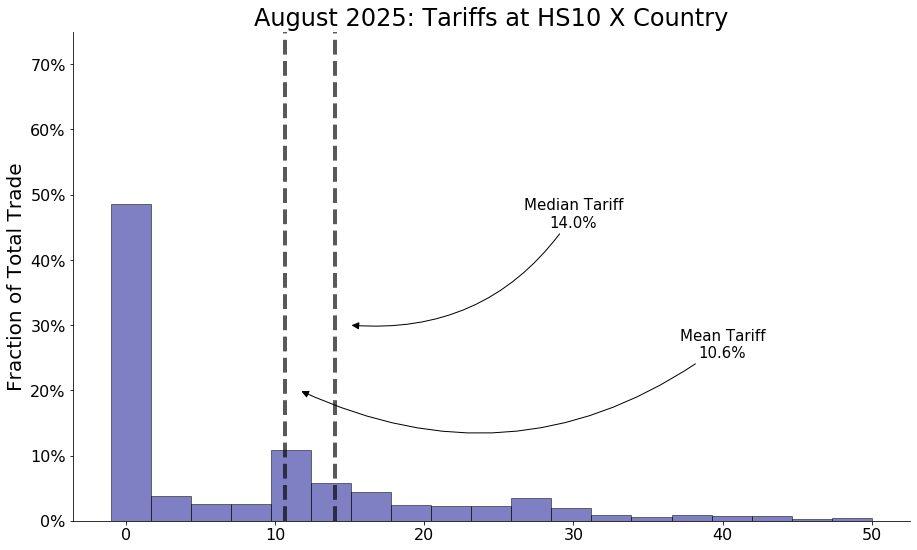

In [21]:
fig, ax = plt.subplots(figsize = (15,9))

bin_edges = np.linspace(-1, 50, 20)  # 50 bins

# Digitize delta_tariff into bins
bin_indices = np.digitize(foo["applied_tariff"], bin_edges) - 1

# Sum CON_VAL_MO in each bin
bin_sums = np.zeros(len(bin_edges) - 1)

for i in range(len(bin_sums)):

    bin_sums[i] = foo.loc[bin_indices == i, "CON_VAL_MO"].sum()

# Convert to fraction of total CON_VAL_MO
fractions = bin_sums / foo["CON_VAL_MO"].sum()

ax.bar(bin_edges[:-1], fractions, width=np.diff(bin_edges), 
       align='edge', color='darkblue', alpha=0.5, edgecolor='black')

# ax.set_ylim(top=0.95)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

# ax.set_xlabel("Change in HS10 Tariff: May 2025 - May 2024", fontsize = 20)

ax.set_title("August 2025: Tariffs at HS10 X Country", fontsize = 24)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

mediantariff = foo["applied_tariff"].median()

ax.vlines(mediantariff, 0, 0.75, 
          linestyles= "dashed", color = "k", linewidth=4, alpha=0.65)

ax.annotate("Median Tariff\n{:.1f}%".format(mediantariff), 
            xy=(mediantariff+1, 0.3), 
            xytext=(30, 0.45),
            arrowprops={
            "arrowstyle": "-|>", # This is stuff about the arrow
            "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
            "color": "black"},
            fontsize=15, color='black',
            ha='center')

meantariff = 100*( foo["CAL_DUT_MO"].sum() / foo["CON_VAL_MO"].sum())

ax.vlines(meantariff, 0, 0.75, 
          linestyles= "dashed", color = "k", linewidth=4, alpha=0.65)

ax.annotate("Mean Tariff\n{:.1f}%".format(meantariff), 
            xy=(meantariff+1, 0.20), 
            xytext=(40, 0.25),
            arrowprops={
            "arrowstyle": "-|>", # This is stuff about the arrow
            "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
            "color": "black"},
            fontsize=15, color='black',
            ha='center')

ax.set_ylim(top=0.75)

plt.savefig(figfile+"aug2025-histogram.png", bbox_inches = "tight")

plt.savefig(figfile+"aug2025-histogram.pdf", bbox_inches = "tight")

plt.show()

<Figure size 432x288 with 0 Axes>

In [16]:
foo = df.set_index("time").loc["2024-08"].copy()

foo["applied_tariff"] = foo["applied_tariff"]

foo.head()

,CTY_NAME,CON_VAL_MO,CAL_DUT_MO,I_COMMODITY,I_COMMODITY_SDESC,COMM_LVL,CTY_CODE,applied_tariff
time,,,,,,,,
2024-08-01,CHINA,2300.0,173.0,0106199120,"DOGS, LIVE",HS10,5700,7.521739
2024-08-01,CHINA,1275620.0,95675.0,0106199195,"MAMMALS, LIVE, NESOI",HS10,5700,7.500274
2024-08-01,CHINA,14590.0,1094.0,0106200000,"REPTILES (INCLUDING SNAKES AND TURTLES), LIVE",HS10,5700,7.498286
2024-08-01,CHINA,92578.0,6944.0,0106490090,"INSECTS, LIVE, NESOI",HS10,5700,7.500702
2024-08-01,CHINA,2160.0,162.0,0106900110,"WORMS, LIVE",HS10,5700,7.500000


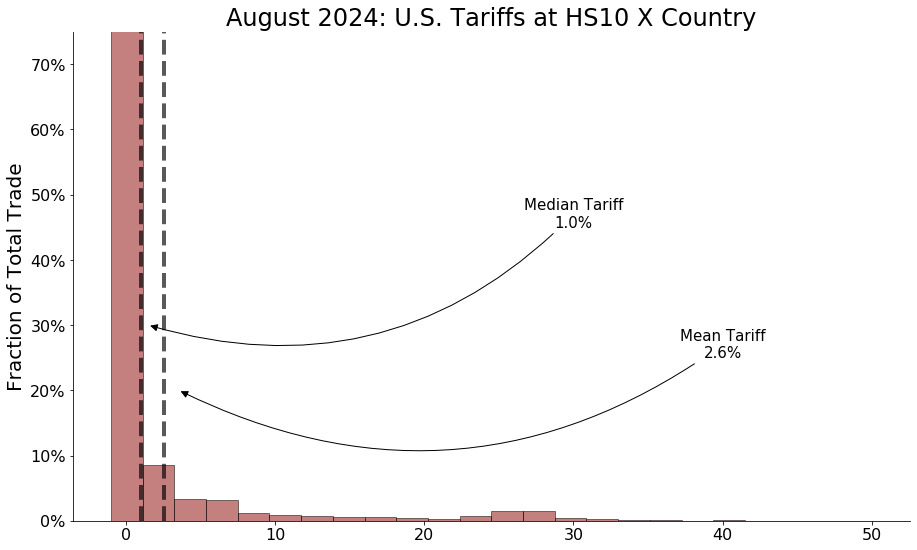

In [18]:
fig, ax = plt.subplots(figsize = (15,9))

bin_edges = np.linspace(-1, 50, 25)  # 50 bins

# Digitize delta_tariff into bins
bin_indices = np.digitize(foo["applied_tariff"], bin_edges) - 1

# Sum CON_VAL_MO in each bin
bin_sums = np.zeros(len(bin_edges) - 1)

for i in range(len(bin_sums)):

    bin_sums[i] = foo.loc[bin_indices == i, "CON_VAL_MO"].sum()

# Convert to fraction of total CON_VAL_MO
fractions = bin_sums / foo["CON_VAL_MO"].sum()

ax.bar(bin_edges[:-1], fractions, width=np.diff(bin_edges), 
       align='edge', color='darkred', alpha=0.5, edgecolor='black')
# ax.set_ylim(top=0.95)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

# ax.set_xlabel("Change in HS10 Tariff: May 2025 - May 2024", fontsize = 20)

ax.set_title("August 2024: U.S. Tariffs at HS10 X Country", fontsize = 24)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

mediantariff = foo["applied_tariff"].median()

ax.vlines(mediantariff, 0, 0.75, 
          linestyles= "dashed", color = "k", linewidth=4, alpha=0.65)

ax.annotate("Median Tariff\n{:.1f}%".format(mediantariff), 
            xy=(mediantariff+0.5, 0.3), 
            xytext=(30, 0.45),
            arrowprops={
            "arrowstyle": "-|>", # This is stuff about the arrow
            "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
            "color": "black"},
            fontsize=15, color='black',
            ha='center')

meantariff = 100*( foo["CAL_DUT_MO"].sum() / foo["CON_VAL_MO"].sum())

ax.vlines(meantariff, 0, 0.75, 
          linestyles= "dashed", color = "k", linewidth=4, alpha=0.65)

ax.annotate("Mean Tariff\n{:.1f}%".format(meantariff), 
            xy=(meantariff+1, 0.20), 
            xytext=(40, 0.25),
            arrowprops={
            "arrowstyle": "-|>", # This is stuff about the arrow
            "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
            "color": "black"},
            fontsize=15, color='black',
            ha='center')

ax.set_ylim(top=0.75)

plt.savefig(figfile+"aug2024-histogram.png", bbox_inches = "tight")

plt.savefig(figfile+"aug2024-histogram.pdf", bbox_inches = "tight")

plt.show()